<a href="https://colab.research.google.com/github/JacopoMauro21/progetto_ipcv/blob/main/assignment_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import random_split, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm.notebook import tqdm
import numpy as np
import random
from torchvision.models import resnet18, ResNet18_Weights

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(seed=42)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'device: {device}')

device: cuda


In [2]:
# transform=None → we get raw PIL images, we handle the transform later
base_trainval = torchvision.datasets.FGVCAircraft(
    root='./data', split='trainval', annotation_level='variant',
    download=True, transform=None)

base_test = torchvision.datasets.FGVCAircraft(
    root='./data', split='test', annotation_level='variant',
    download=True, transform=None)

print(f"Trainval images: {len(base_trainval)} - test: {len(base_test)}")

100%|██████████| 2.75G/2.75G [01:49<00:00, 25.2MB/s]


Trainval images: 6667 - test: 3333


In [3]:
class_names = base_trainval.classes
print(len(class_names))

100


In [4]:
val_split = 0.2
n = len(base_trainval)
val_size = int(n * val_split)

g = torch.Generator().manual_seed(42)
perm = torch.randperm(n, generator=g).tolist()

val_indices   = perm[:val_size]
train_indices = perm[val_size:]

print(f"Training: {len(train_indices)} - Validation: {len(val_indices)}")

Training: 5334 - Validation: 1333


In [5]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

# SLOW and deterministic → applied only ONCE and cached
pre_resize = transforms.Resize((146, 146))

# LIGHT and random → applied at each epoch (augmentation must remain active)
train_aug = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    # transforms.RandomErasing(p=0.25),
])

# Full augmentation (with erasing) — the new default
train_aug_full = transforms.Compose([
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25),
])

# Evaluation: deterministic
eval_aug = transforms.Compose([
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    normalize,
])

In [6]:
class CachedAircraft(Dataset):
    def __init__(self, base, indices, pre, aug):
        self.aug = aug
        self.cache = []
        for i in tqdm(indices, desc="caching"):
            img, label = base[i]
            self.cache.append((pre(img), label))

    def set_aug(self, aug):
        self.aug = aug

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, label = self.cache[idx]
        return self.aug(img), label

In [7]:
train_ds = CachedAircraft(base_trainval, train_indices, pre_resize, train_aug)
val_ds   = CachedAircraft(base_trainval, val_indices,   pre_resize, eval_aug)
test_ds  = CachedAircraft(base_test, list(range(len(base_test))), pre_resize, eval_aug)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=batch_size, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, num_workers=2)

caching:   0%|          | 0/5334 [00:00<?, ?it/s]

caching:   0%|          | 0/1333 [00:00<?, ?it/s]

caching:   0%|          | 0/3333 [00:00<?, ?it/s]

In [ ]:
import time
t = time.time()
for imgs, labels in train_dl:
    imgs = imgs.to(device)
print(f"Only data loading: {time.time()-t:.1f}s")

Only data loading: 6.8s


In [ ]:
import torch.nn as nn
import torch

class SimpleAircraftCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 128 -> 64
            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 64 -> 32
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32 -> 16
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16 -> 8
            nn.AdaptiveAvgPool2d((1, 1)),                            # -> 512 x 1 x 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
model = SimpleAircraftCNN(num_classes=100).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0) # , weight_decay=5e-4

In [8]:
def ncorrect(scores, y):
    y_hat = torch.argmax(scores, -1)
    return (y_hat == y).sum()

def accuracy(scores, y):
    correct = ncorrect(scores, y)
    return correct.true_divide(y.shape[0])

def train_loop(model, train_dl, epochs, opt, val_dl=None, scheduler=None, verbose=False):
    best_val_acc = 0
    best_train = 0
    best_params = []
    best_epoch = -1

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for e in tqdm(range(epochs)):
        model.train()
        train_loss = 0
        train_samples = 0
        train_acc = 0
        for train_data in train_dl:
            imgs = train_data[0].to(device)
            labels = train_data[1].to(device)
            scores = model(imgs)
            loss = F.cross_entropy(scores, labels, reduction="sum")
            train_loss += loss.item()
            train_samples += imgs.shape[0]
            train_acc += ncorrect(scores, labels).item()

            opt.zero_grad()
            loss.backward()
            opt.step()

        train_acc /= train_samples
        train_loss /= train_samples

        model.eval()
        with torch.no_grad():
            val_loss = 0
            val_samples = 0
            val_acc = 0
            if val_dl is not None:
                for val_data in val_dl:
                    imgs = val_data[0].to(device)
                    labels = val_data[1].to(device)
                    val_scores = model(imgs)
                    val_loss += F.cross_entropy(val_scores, labels, reduction="sum").item()
                    val_samples += imgs.shape[0]
                    val_acc += ncorrect(val_scores, labels).item()
                val_acc /= val_samples
                val_loss /= val_samples

            if val_dl is None or val_acc > best_val_acc:
                best_val_acc = val_acc if val_dl is not None else 0
                best_train = train_acc
                best_params = model.state_dict()
                torch.save(best_params, "best_model.pth")
                best_epoch = e

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss if val_dl is not None else None)
        history["val_acc"].append(val_acc if val_dl is not None else None)

        if verbose and e % 5 == 0:
            tqdm.write(f"Epoch {e}: train loss {train_loss:.3f} - train acc {train_acc:.3f}" + ("" if val_dl is None else f" - valid loss {val_loss:.3f} - valid acc {val_acc:.3f}"))

    if verbose and val_dl is not None:
        tqdm.write(f"Best epoch {best_epoch}, best acc {best_val_acc}, best train {best_train}")

    return best_val_acc, best_params, best_epoch, best_train, history

In [ ]:
epochs = 100
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc, best_params, best_epoch, best_train, _ = train_loop(
    model,
    train_dl,
    epochs,
    optimizer,
    val_dl,
    scheduler=scheduler,
    verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: train loss 4.646 - train acc 0.020 - valid loss 4.504 - valid acc 0.030
Epoch 5: train loss 4.022 - train acc 0.077 - valid loss 4.087 - valid acc 0.084
Epoch 10: train loss 3.431 - train acc 0.142 - valid loss 3.762 - valid acc 0.098
Epoch 15: train loss 3.053 - train acc 0.217 - valid loss 3.385 - valid acc 0.171
Epoch 20: train loss 2.698 - train acc 0.297 - valid loss 3.006 - valid acc 0.229
Epoch 25: train loss 2.400 - train acc 0.356 - valid loss 2.981 - valid acc 0.248
Epoch 30: train loss 2.126 - train acc 0.422 - valid loss 2.582 - valid acc 0.323
Epoch 35: train loss 1.895 - train acc 0.475 - valid loss 2.311 - valid acc 0.381
Epoch 40: train loss 1.706 - train acc 0.530 - valid loss 2.370 - valid acc 0.388
Epoch 45: train loss 1.525 - train acc 0.579 - valid loss 2.042 - valid acc 0.470
Epoch 50: train loss 1.366 - train acc 0.619 - valid loss 2.115 - valid acc 0.460
Epoch 55: train loss 1.254 - train acc 0.651 - valid loss 1.967 - valid acc 0.492
Epoch 60: train lo

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = total = 0
with torch.no_grad():
    for imgs, labels in test_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += ncorrect(model(imgs), labels).item()
        total += imgs.shape[0]

print(f"Test accuracy: {correct/total:.4f}")

Test accuracy: 0.5611


### Ablation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/ipcv_ablation_results'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
import json
import pickle

RESULTS_FILE = os.path.join(SAVE_DIR, "ablation_results.json")
HISTORY_DIR = os.path.join(SAVE_DIR, "histories")
os.makedirs(HISTORY_DIR, exist_ok=True)

def load_existing_results():
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE, "r") as f:
            return json.load(f)
    return {}

def save_result(name, result):
    # separate history (too heavy/nested for a simple json) from the rest
    result_light = {k: v for k, v in result.items() if k != "history"}

    existing = load_existing_results()
    existing[name] = result_light
    with open(RESULTS_FILE, "w") as f:
        json.dump(existing, f, indent=2)

    # save history separately, in pickle (handles lists/None better)
    with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "wb") as f:
        pickle.dump(result["history"], f)

    # also save model weights for that configuration, if you want to reload them later
    # (optional, takes more space)

In [ ]:
class SimpleAircraftCNN_ablation(nn.Module):
    def __init__(self, num_classes=100, use_bn=True, use_dropout=True, dropout_p=0.5):
        super().__init__()
        def bn(ch):
            return nn.BatchNorm2d(ch) if use_bn else nn.Identity()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),    bn(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),  bn(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), bn(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), bn(512), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
def evaluate(model, dl):
  model.eval()
  correct = total = 0
  with torch.no_grad():
      for imgs, labels in dl:
          imgs, labels = imgs.to(device), labels.to(device)
          correct += ncorrect(model(imgs), labels).item()
          total += imgs.shape[0]
  accuracy = correct/total
  return accuracy

In [ ]:
BASE_CONFIG = dict(
    use_bn=True, use_dropout=True, dropout_p=0.5,
    use_augmentation=True, use_erasing=True,
    weight_decay=0.0, use_scheduler=True,
)

ablations = {
    "full_model":        BASE_CONFIG,
    "no_batchnorm":      {**BASE_CONFIG, "use_bn": False},
    "no_dropout":        {**BASE_CONFIG, "use_dropout": False},
    "no_augmentation":   {**BASE_CONFIG, "use_augmentation": False, "use_erasing": False},
    "no_erasing":        {**BASE_CONFIG, "use_erasing": False},
    "no_scheduler":      {**BASE_CONFIG, "use_scheduler": False},
}

In [ ]:
def select_aug(config):
    if not config["use_augmentation"]:
        return eval_aug
    return train_aug_full if config["use_erasing"] else train_aug

In [ ]:
def run_ablation(name, config, epochs=100, seed=42):
    torch.manual_seed(seed)

    train_ds.set_aug(select_aug(config))
    train_dl_ab = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    model = SimpleAircraftCNN_ablation(
        num_classes=100,
        use_bn=config["use_bn"],
        use_dropout=config["use_dropout"],
        dropout_p=config["dropout_p"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,
                                  weight_decay=config["weight_decay"])
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if config["use_scheduler"] else None)

    best_val_acc, best_params, best_epoch, best_train, history = train_loop(
        model, train_dl_ab, epochs, optimizer, val_dl,
        scheduler=scheduler, verbose=False
    )

    model.load_state_dict(best_params)
    test_acc = evaluate(model, test_dl)

    # train_ds.set_aug(eval_aug)
    # train_eval_dl = DataLoader(train_ds, batch_size=batch_size, num_workers=2)
    # train_acc_final = evaluate(model, train_eval_dl)

    gap = best_train - test_acc

    return {"name": name, "test_acc": test_acc, "train_acc": best_train,
            "gap": gap, "best_epoch": best_epoch, "history": history}

In [ ]:
existing_results = load_existing_results()
results = []

for name, cfg in ablations.items():
    if name in existing_results:
        print(f"[SKIP] '{name}' already completed, loading from save.")
        r = existing_results[name]
        with open(os.path.join(HISTORY_DIR, f"{name}.pkl"), "rb") as f:
            r["history"] = pickle.load(f)
        results.append(r)
        continue

    print(f"[RUN] Starting ablation: {name}")
    r = run_ablation(name, cfg)
    save_result(name, r)
    results.append(r)
    print(f"[DONE] '{name}': test_acc={r['test_acc']:.4f}, gap={r['gap']:.4f}")

[SKIP] 'full_model' already completed, loading from save.
[SKIP] 'no_batchnorm' already completed, loading from save.
[SKIP] 'no_dropout' already completed, loading from save.
[SKIP] 'no_augmentation' already completed, loading from save.
[SKIP] 'no_erasing' already completed, loading from save.
[SKIP] 'no_scheduler' already completed, loading from save.


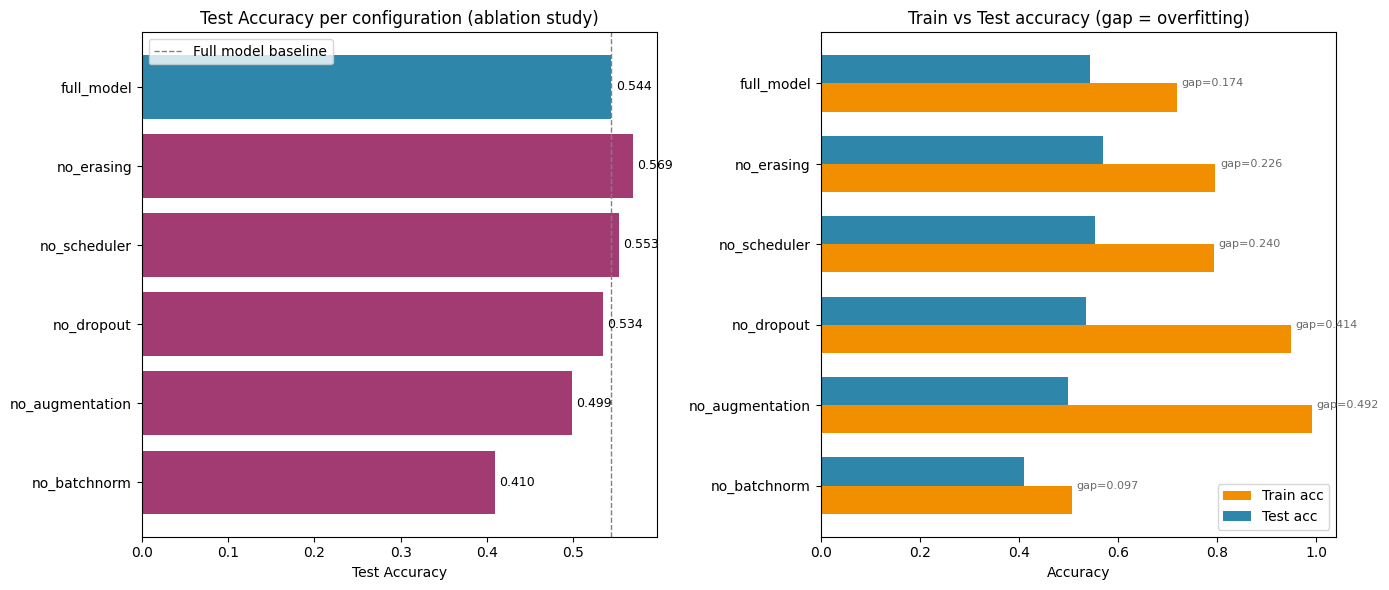

           name  test_acc  train_acc    gap  best_epoch
     full_model    0.5443     0.7184 0.1742          86
     no_erasing    0.5692     0.7955 0.2263          97
   no_scheduler    0.5527     0.7930 0.2404          91
     no_dropout    0.5344     0.9483 0.4139          90
no_augmentation    0.4986     0.9908 0.4922          87
   no_batchnorm    0.4095     0.5066 0.0970          90


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# order by putting full_model at the top, then others by decreasing test_acc
df["is_full"] = df["name"] == "full_model"
df = df.sort_values(["is_full", "test_acc"], ascending=[False, False]).drop(columns="is_full")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#2E86AB" if n == "full_model" else "#A23B72" for n in df["name"]]

# --- Plot 1: Test accuracy per configuration ---
ax = axes[0]
bars = ax.barh(df["name"], df["test_acc"], color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Test Accuracy per configuration (ablation study)")
ax.axvline(df.loc[df["name"] == "full_model", "test_acc"].values[0],
           color="gray", linestyle="--", linewidth=1, label="Full model baseline")
ax.legend()
ax.invert_yaxis()  # full_model at the top
for bar, val in zip(bars, df["test_acc"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=9)

# --- Plot 2: Train/Test accuracy side by side + gap ---
ax = axes[1]
y = np.arange(len(df))
height = 0.35
ax.barh(y + height/2, df["train_acc"], height=height, label="Train acc", color="#F18F01")
ax.barh(y - height/2, df["test_acc"], height=height, label="Test acc", color="#2E86AB")
ax.set_yticks(y)
ax.set_yticklabels(df["name"])
ax.set_xlabel("Accuracy")
ax.set_title("Train vs Test accuracy (gap = overfitting)")
ax.invert_yaxis()
ax.legend()

# annotate the gap next to each row
for i, (train_a, gap) in enumerate(zip(df["train_acc"], df["gap"])):
    ax.text(train_a + 0.01, i, f"gap={gap:.3f}", va="center", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig("ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Ordered summary table ---
print(df[["name", "test_acc", "train_acc", "gap", "best_epoch"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

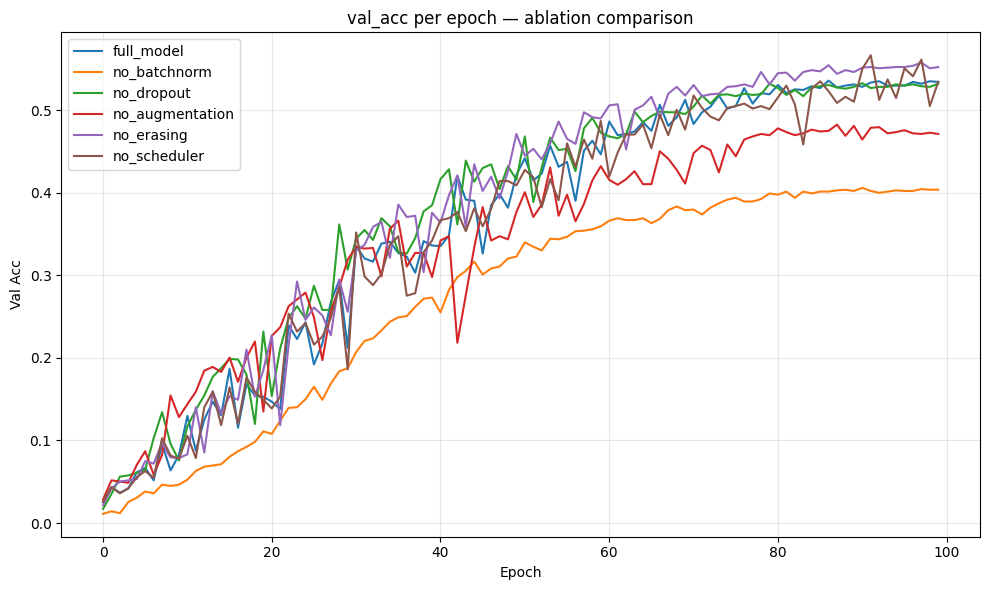

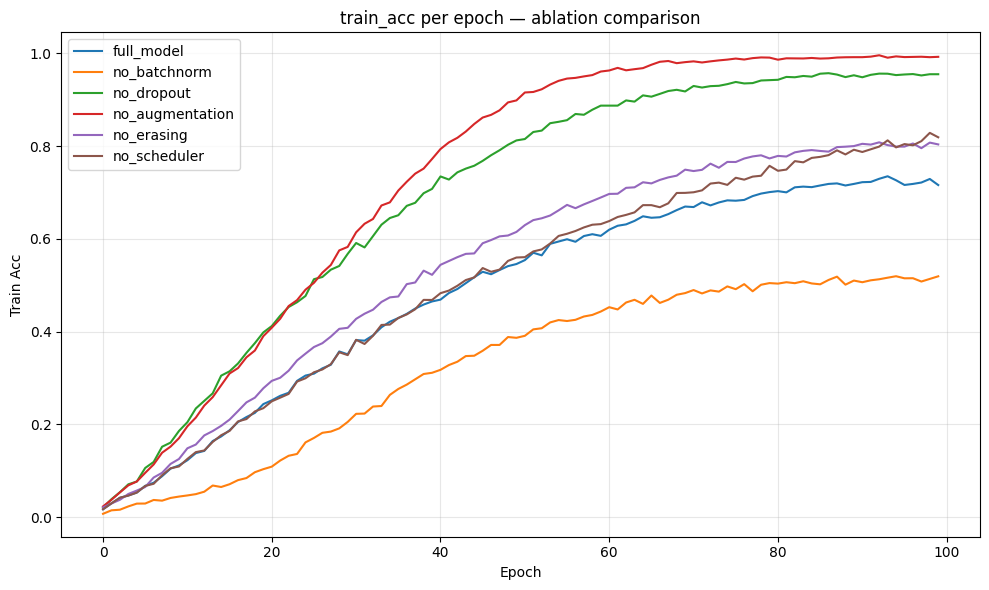

In [ ]:
def plot_training_curves(results, metric="val_acc", title=None):
    plt.figure(figsize=(10, 6))
    for r in results:
        epochs_range = range(len(r["history"][metric]))
        plt.plot(epochs_range, r["history"][metric], label=r["name"])
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or f"{metric} per epoch — ablation comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"ablation_{metric}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(results, metric="val_acc")
plot_training_curves(results, metric="train_acc")

In [14]:
def plot_train_vs_val(result, title=None):
    h = result["history"]
    epochs_range = range(len(h["train_acc"]))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["train_acc"], label="Train acc")
    plt.plot(epochs_range, h["val_acc"], label="Val acc")
    plt.fill_between(epochs_range,
                      h["train_acc"], h["val_acc"],
                      alpha=0.15, color="red", label="Gap")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title or f"{result['name']}: train vs val accuracy over time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

full_model_result = next(r for r in results if r["name"] == "full_model")
plot_train_vs_val(full_model_result)

NameError: name 'results' is not defined

## Part 2

In [ ]:
## 2A

fix_random(seed=42)

# --- model ---
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

# --- same hyperparameters used in Part 1 ---
epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Reset of train_ds since it was modified during training
train_ds.set_aug(train_aug_full)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)

best_val_acc, best_params, best_epoch, best_train, history = train_loop(
    model, train_dl, epochs, optimizer, val_dl, scheduler=scheduler, verbose=True
)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: train loss 3.831 - train acc 0.122 - valid loss 4.328 - valid acc 0.075
Epoch 5: train loss 1.193 - train acc 0.642 - valid loss 1.744 - valid acc 0.502
Epoch 10: train loss 0.661 - train acc 0.792 - valid loss 1.616 - valid acc 0.577
Epoch 15: train loss 0.448 - train acc 0.859 - valid loss 1.587 - valid acc 0.598
Epoch 20: train loss 0.309 - train acc 0.906 - valid loss 1.567 - valid acc 0.638
Epoch 25: train loss 0.232 - train acc 0.932 - valid loss 1.706 - valid acc 0.614
Epoch 30: train loss 0.222 - train acc 0.930 - valid loss 1.759 - valid acc 0.616
Epoch 35: train loss 0.166 - train acc 0.950 - valid loss 1.545 - valid acc 0.658
Epoch 40: train loss 0.127 - train acc 0.963 - valid loss 1.523 - valid acc 0.668
Epoch 45: train loss 0.118 - train acc 0.964 - valid loss 1.440 - valid acc 0.695
Epoch 50: train loss 0.088 - train acc 0.974 - valid loss 1.485 - valid acc 0.690
Epoch 55: train loss 0.077 - train acc 0.979 - valid loss 1.410 - valid acc 0.696
Epoch 60: train lo

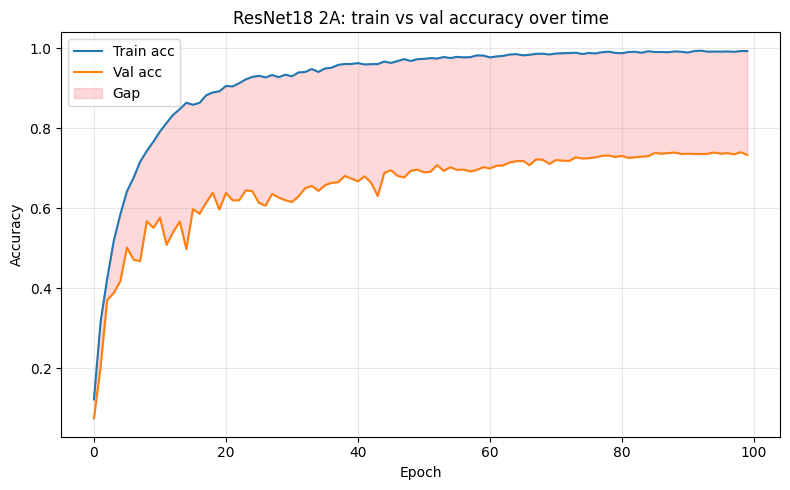

In [ ]:
resnet_ft_result = {
    "name": "ResNet18 2A",
    "history": history
}
plot_train_vs_val(resnet_ft_result)


# Part 2B — changes compared to 2A

# Diagnosis from 2A: severe overfitting (train_acc ≈ 0.99, val_acc ≈ 0.74,
# persistent gap throughout training, val still slightly rising
# at epoch 98/100 → the model does not "collapse", but generalizes poorly).
#
# Resolution, epochs, batch size, scheduler, and augmentation (train_aug_full,
# with RandomErasing) remain unchanged compared to 2A, to isolate
# the effect of the following changes only:
#
# 1: Optimizer: Adam -> AdamW
#    Adam applies the L2 penalty coupled with the gradient; AdamW decouples it, making weight decay more effective as a proper regularizer.
#[[Loshchilov & Hutter, "Decoupled Weight Decay Regularization", 2019](https://arxiv.org/abs/1711.05101)].
#
# 2: Weight decay: 0.0 -> 5e-4
#    In 2A there was no explicit regularization on the weights;
#    a non-zero value should reduce the train/val gap.
#
# 3: Learning rate: single lr=1e-3 on all parameters -> differentiated lr per parameter groups:
#       - backbone (features pretrained on ImageNet): lr=1e-4
#       - fc (new classifier, initialized from scratch): lr=1e-3
#    Motivation: a high and uniform lr risks altering the pretrained features of the backbone too rapidly, while the new fc needs a higher lr to converge in a reasonable time.
#[[Yosinski et al., "How transferable are features in deep neural networks?", 2014](https://proceedings.neurips.cc/paper_files/paper/2014/hash/532a2f85b6977104bc93f8580abbb330-Abstract.html)].

In [16]:
# --- Nuova cella: transform a risoluzione più alta (224px) ---

pre_resize_224 = transforms.Resize((256, 256))

train_aug_224 = transforms.Compose([
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25),
])

eval_aug_224 = transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

In [17]:
# --- Nuova cella: ri-caching dei dataset a 224px ---

train_ds_224 = CachedAircraft(base_trainval, train_indices, pre_resize_224, train_aug_224)
val_ds_224   = CachedAircraft(base_trainval, val_indices,   pre_resize_224, eval_aug_224)
test_ds_224  = CachedAircraft(base_test, list(range(len(base_test))), pre_resize_224, eval_aug_224)

batch_size_224 = 64  # ridotto rispetto a 128: le immagini a 224px occupano ~3x la memoria di quelle a 128px

train_dl_224 = DataLoader(train_ds_224, batch_size=batch_size_224, shuffle=True, num_workers=2)
val_dl_224   = DataLoader(val_ds_224,   batch_size=batch_size_224, num_workers=2)
test_dl_224  = DataLoader(test_ds_224,  batch_size=batch_size_224, num_workers=2)

print(f"Cached at 224px — train: {len(train_ds_224)}, val: {len(val_ds_224)}, test: {len(test_ds_224)}")

caching:   0%|          | 0/5334 [00:00<?, ?it/s]

caching:   0%|          | 0/1333 [00:00<?, ?it/s]

caching:   0%|          | 0/3333 [00:00<?, ?it/s]

Cached at 224px — train: 5334, val: 1333, test: 3333


In [19]:
fix_random(seed=42)

model_2b = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_2b.fc = nn.Linear(model_2b.fc.in_features, 100)
model_2b = model_2b.to(device)


train_ds.set_aug(train_aug_full)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)

backbone_params = [p for n, p in model_2b.named_parameters() if not n.startswith("fc")]
fc_params       = [p for n, p in model_2b.named_parameters() if n.startswith("fc")]

epochs = 60
optimizer_2b = torch.optim.AdamW([
    {"params": backbone_params, "lr": 2e-4},
    {"params": fc_params,       "lr": 1e-3},
])

scheduler_2b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_2b, T_max=epochs)

In [20]:
best_val_acc_2b, best_params_2b, best_epoch_2b, best_train_2b, history_2b = train_loop(
    model_2b, train_dl_224, epochs, optimizer_2b, val_dl_224,
    scheduler=scheduler_2b, verbose=True)

print(f"Best epoch: {best_epoch_2b}, best val acc: {best_val_acc_2b:.4f}, best train acc: {best_train_2b:.4f}")

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch 0: train loss 3.503 - train acc 0.202 - valid loss 2.286 - valid acc 0.370
Epoch 5: train loss 0.467 - train acc 0.871 - valid loss 1.079 - valid acc 0.687
Epoch 10: train loss 0.205 - train acc 0.945 - valid loss 1.023 - valid acc 0.715
Epoch 15: train loss 0.158 - train acc 0.955 - valid loss 0.954 - valid acc 0.739
Epoch 20: train loss 0.100 - train acc 0.971 - valid loss 0.907 - valid acc 0.765
Epoch 25: train loss 0.080 - train acc 0.980 - valid loss 1.008 - valid acc 0.746
Epoch 30: train loss 0.069 - train acc 0.980 - valid loss 0.905 - valid acc 0.781
Epoch 35: train loss 0.054 - train acc 0.985 - valid loss 0.903 - valid acc 0.776
Epoch 40: train loss 0.034 - train acc 0.991 - valid loss 0.852 - valid acc 0.785
Epoch 45: train loss 0.031 - train acc 0.993 - valid loss 0.792 - valid acc 0.802
Epoch 50: train loss 0.028 - train acc 0.991 - valid loss 0.778 - valid acc 0.804
Epoch 55: train loss 0.024 - train acc 0.993 - valid loss 0.777 - valid acc 0.800
Best epoch 52, bes

Test accuracy 2B: 0.8080


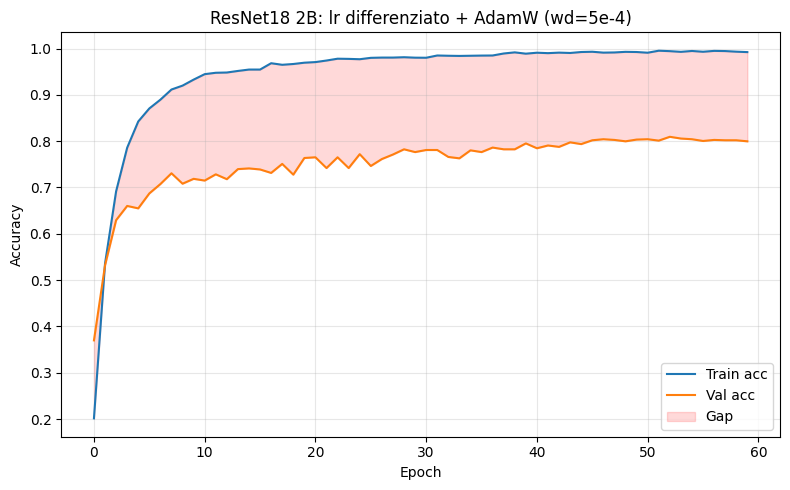

In [21]:
model_2b.load_state_dict(torch.load("best_model.pth"))
test_acc_2b = evaluate(model_2b, test_dl_224)
print(f"Test accuracy 2B: {test_acc_2b:.4f}")

plot_train_vs_val({"name": "ResNet18 2B", "history": history_2b}, title="ResNet18 2B: lr differenziato + AdamW (wd=5e-4)")